<a href="https://colab.research.google.com/github/jth202515033/special/blob/20250404/0404.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 49.7M/49.7M [00:00<00:00, 56.0MB/s]


Saving 1.png to 1 (1).png

0: 352x640 19 persons, 4 backpacks, 11 umbrellas, 4 handbags, 2 chairs, 1 dining table, 931.7ms
Speed: 5.4ms preprocess, 931.7ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)
✅ 이 이미지에는 19명의 사람이 감지되었습니다.


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


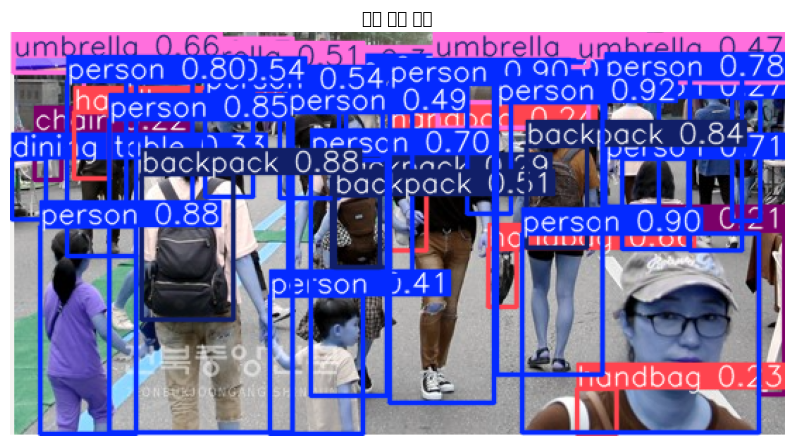

In [ ]:
!pip install ultralytics opencv-python-headless -q

# 📚 라이브러리 불러오기
from ultralytics import YOLO
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# ✅ 더 정밀한 모델 로드 (중간 크기 모델 사용)
model = YOLO('yolov8m.pt')  # nano(n)보다 정확함

# 📤 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# 🖼️ 이미지 불러오기
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 🔍 사람 감지 실행 (신뢰도 기준 낮춰서 더 많이 탐지)
results = model(image_rgb, conf=0.2)  # conf 낮추면 더 민감하게 탐지

# 📌 사람만 찾기 (class_id == 0)
person_boxes = []
for result in results:
    for box in result.boxes:
        if int(box.cls) == 0:
            person_boxes.append(box)

# ✅ 결과 출력
if len(person_boxes) > 0:
    print(f"✅ 이 이미지에는 {len(person_boxes)}명의 사람이 감지되었습니다.")
else:
    print("❌ 이 이미지에는 사람이 감지되지 않았습니다.")

# 🎨 결과 이미지 표시
image_with_boxes = results[0].plot()
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("사람 감지 결과")
plt.show()


[링크 텍스트](https://)https://youtube.com/shorts/DonB37sEEsg?si=ksHAOnMTtCnj-l0h

1. ultralytics 다운로드


In [8]:
!pip install -q ultralytics yt-dlp opencv-python moviepy

# 📌 2. 라이브러리 불러오기
import cv2
import os
import shutil
import glob
import numpy as np
from ultralytics import YOLO
from moviepy.editor import VideoFileClip
from IPython.display import display, HTML, Video
from yt_dlp import YoutubeDL

# 📌 3. 유튜브 영상 다운로드 함수
def download_youtube_video(youtube_url, output_filename="input_video.mp4"):
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',
        'outtmpl': output_filename,
        'merge_output_format': 'mp4',
        'quiet': False
    }
    with YoutubeDL(ydl_opts) as ydl:
        ydl.download([youtube_url])
    return output_filename

# 📌 4. YOLO를 이용한 차량 감지 함수
def detect_cars(input_video, output_video="output_video.mp4"):
    model = YOLO('yolov8n.pt')  # YOLOv8 모델 로드 (nano 버전)

    cap = cv2.VideoCapture(input_video)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    car_classes = [2, 5, 7]  # 자동차, 버스, 트럭 클래스 ID

    print("🚗 차량 감지 시작...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=0.3)  # YOLO 실행
        for result in results:
            for box in result.boxes:
                class_id = int(box.cls)
                if class_id in car_classes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    label = model.names[class_id]
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, label, (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        out.write(frame)

    cap.release()
    out.release()
    print(f"✅ 차량 감지 완료! 결과 저장: {output_video}")

# 📌 5. Colab에서 동영상 재생하는 함수
def show_video(video_path):
    return Video(video_path, embed=True)

# 🔥 실행 시작!
youtube_url = "https://youtube.com/shorts/DonB37sEEsg?si=ksHAOnMTtCnj-l0h"  # 👉 감지할 유튜브 영상 링크
input_video = "input_video.mp4"
output_video = "output_video.mp4"

# 🎥 1. 유튜브 영상 다운로드
download_youtube_video(youtube_url, input_video)

# 🚗 2. 차량 감지 실행
detect_cars(input_video, output_video)

# 🎬 3. 결과 영상 Colab에서 확인
show_video(output_video)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.6 MB/s eta 0:00:00
[youtube] Extracting URL: https://youtube.com/shorts/DonB37sEEsg?si=ksHAOnMTtCnj-l0h
[youtube] DonB37sEEsg: Downloading webpage
[youtube] DonB37sEEsg: Downloading tv client config
[youtube] DonB37sEEsg: Downloading player 73381ccc-main
[youtube] DonB37sEEsg: Downloading tv player API JSON
[youtube] DonB37sEEsg: Downloading ios player API JSON
[youtube] DonB37sEEsg: Downloading m3u8 information
[info] DonB37sEEsg: Downloading 1 format(s): 398+140
[download] Destination: input_video.f398.mp4
[download] 100% of    4.93MiB in 00:00:00 at 13.91MiB/s  
[download] Destination: input_video.f140.m4a
[download] 100% of    1.02MiB in 00:00:00 at 14.14MiB/s  
[Merger] Merging formats into "input_video.mp4"
Deleting original file input_video.f398.mp4 (pass -k to keep)
Deleting original file input_video.f140.m4a (pass -k to keep)


100%|██████████| 6.25M/6.25M [00:00<00:00, 89.4MB/s]


🚗 차량 감지 시작...
✅ 차량 감지 완료! 결과 저장: output_video.mp4


In [6]:
!pip install -q --upgrade ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.3/977.3 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 24.7 MB/s eta 0:00:00
